In [3]:
from pathlib import Path
import pandas as pd

# 查找当前项目目录中的所有xlsx文件
xlsx_files = list(Path.cwd().rglob("*.xlsx"))

if not xlsx_files:
    raise FileNotFoundError("当前项目中未找到任何xlsx文件。")

# 如果有多个xlsx文件，可以选择第一个，或者根据需求做进一步选择
excel_path = xlsx_files[0]

print(f"已找到文件: {excel_path.resolve()}")
df = pd.read_excel(excel_path)
display(df.shape)
df.head()


已找到文件: D:\programming\python_script\socio-physical system for shelter\data_empirical\336170440_30000_坐标数据.xlsx


(133, 3)

,答卷序号,点选坐标,提交时间
0,1,364-192→300-226→338-192→322-496→308-148,2025-10-30 10:59:52
1,2,365-210→317-230→159-266→397-220→452-276,2025-10-30 11:01:51
2,3,258-458→357-223→591-661→320-217→506-432,2025-10-30 11:03:48
3,4,342-172→166-260→278-434→415-455→425-588→324-44...,2025-10-30 11:04:59
4,5,321-131→200-175→111-262→361-169→472-407→326-46...,2025-10-30 11:08:38


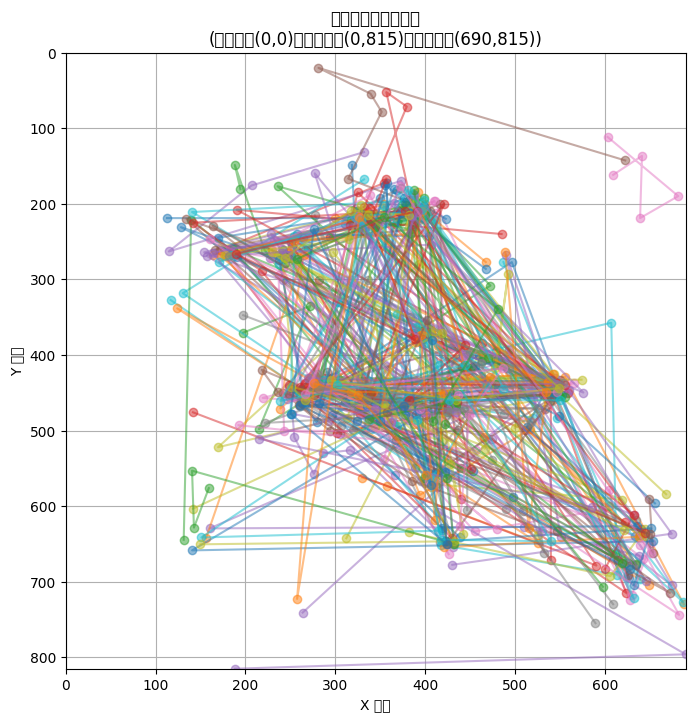

In [ ]:
import matplotlib.pyplot as plt

# 假设"点选坐标"这一列存在，并且用→分隔每一对
def parse_coords(coord_str):
    points = coord_str.split('→')
    point_list = []
    for pt in points:
        try:
            x_str, y_str = pt.split('-')
            point_list.append((int(x_str), int(y_str)))
        except Exception as e:
            pass
    return point_list

# 新建一列，将字符串转为点对列表
df['点对'] = df['点选坐标'].apply(parse_coords)

# 计算原始坐标范围（用于缩放到目标坐标系）
raw_max_x, raw_max_y = 0, 0
for points in df['点对']:
    for x, y in points:
        if x > raw_max_x:
            raw_max_x = x
        if y > raw_max_y:
            raw_max_y = y

# 目标坐标系：左上(0,0)、左下(0,815)、右上(690,815)
target_width, target_height = 690, 815
x_scale = (target_width / raw_max_x) if raw_max_x else 1
y_scale = (target_height / raw_max_y) if raw_max_y else 1

# 可视化所有点对（左上角为(0,0) 的坐标系）
plt.figure(figsize=(8, 8))
for points in df['点对']:
    xs = [x * x_scale for x, _ in points]
    ys = [y * y_scale for _, y in points]
    plt.plot(xs, ys, marker='o', alpha=0.5)

plt.title('所有答卷的点选轨迹\n(左上角为(0,0)，左下角为(0,815)，右上角为(690,815))')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.xlim(0, target_width)
plt.ylim(target_height, 0)  # 使y轴向下增大
plt.grid(True)
plt.show()





点坐标: (376.55, -192.71)
点坐标: (310.34, -226.83)
点坐标: (349.66, -192.71)
点坐标: (333.10, -497.83)
点坐标: (318.62, -148.55)
点坐标: (377.59, -210.78)
点坐标: (327.93, -230.85)
点坐标: (164.48, -266.98)
点坐标: (410.69, -220.81)
点坐标: (467.59, -277.02)
点坐标: (266.90, -459.69)
点坐标: (369.31, -223.82)
点坐标: (611.38, -663.44)
点坐标: (331.03, -217.80)
点坐标: (523.45, -433.60)
点坐标: (353.79, -172.64)
点坐标: (171.72, -260.96)
点坐标: (287.59, -435.60)
点坐标: (429.31, -456.68)
点坐标: (439.66, -590.17)
点坐标: (335.17, -450.66)
点坐标: (388.97, -370.36)
点坐标: (538.97, -439.62)
点坐标: (293.79, -243.90)
点坐标: (332.07, -131.48)
点坐标: (206.90, -175.65)
点坐标: (114.83, -262.97)
点坐标: (373.45, -169.62)
点坐标: (488.28, -408.50)
点坐标: (337.24, -464.71)
点坐标: (474.83, -510.88)
点坐标: (263.79, -740.73)
点坐标: (400.34, -569.09)
点坐标: (242.07, -449.66)
点坐标: (293.79, -499.84)
点坐标: (398.28, -212.78)
点坐标: (537.93, -433.60)
点坐标: (347.59, -228.84)
点坐标: (242.07, -285.05)
点坐标: (558.62, -448.65)
点坐标: (284.48, -452.67)
点坐标: (180.00, -261.96)
点坐标: (411.72, -211.78)
点坐标: (428.2

d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8F

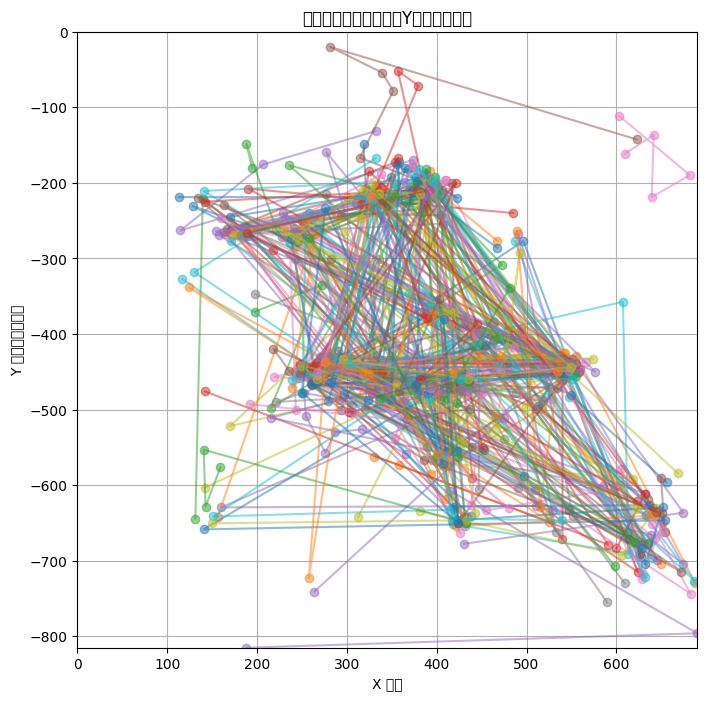

In [34]:
# 可视化所有点对的纵坐标乘以-1后的轨迹，同时输出所有坐标点
plt.figure(figsize=(8, 8))
for points in df['点对']:
    xs = [x * x_scale for x, _ in points]
    ys = [-(y * y_scale) for _, y in points]
    plt.plot(xs, ys, marker='o', alpha=0.5)
    for x_draw, y_draw in zip(xs, ys):
        print(f"点坐标: ({x_draw:.2f}, {y_draw:.2f})")
plt.title('所有答卷的点选轨迹（Y坐标反转后）')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标（已反转）')
plt.xlim(0, target_width)
plt.ylim(-target_height, 0)
plt.grid(True)
plt.show()

,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,-192.709360
1,1,310.344828,-226.834975
2,1,349.655172,-192.709360
3,1,333.103448,-497.832512
4,1,318.620690,-148.546798
...,...,...,...
741,133,424.137931,-562.068966
742,133,257.586207,-273.004926
743,133,353.793103,-216.798030
744,133,481.034483,-339.248768


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6

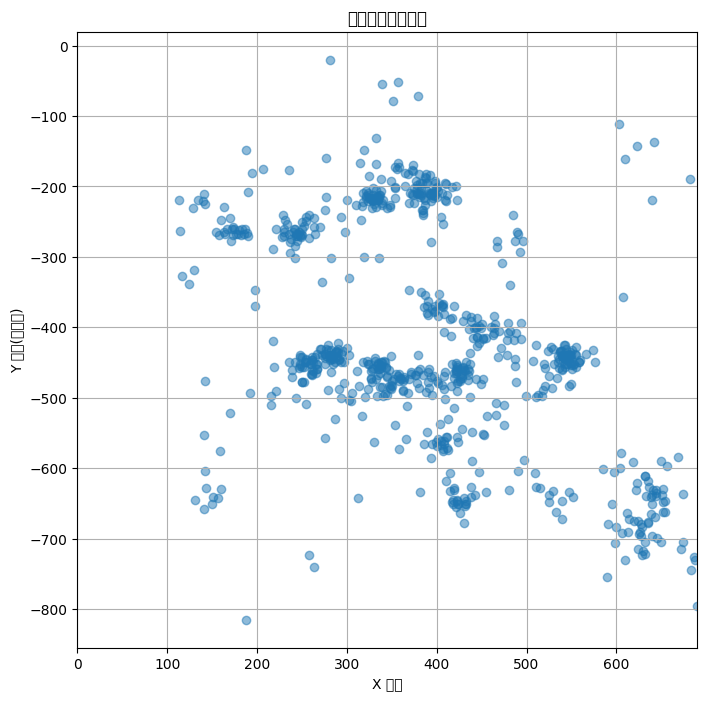

In [35]:

# 输出所有点的坐标组成的DataFrame
all_points = []
for idx, points in enumerate(df['点对']):
    for x, y in points:
        # 这里使用缩放后的坐标，更直观
        scaled_x = x * x_scale
        scaled_y = -(y * y_scale)
        all_points.append({
            '答卷序号': df.iloc[idx]['答卷序号'] if '答卷序号' in df.columns else idx + 1,
            'X坐标': scaled_x,
            'Y坐标(已反转)': scaled_y
        })

points_df = pd.DataFrame(all_points)
display(points_df)

plt.figure(figsize=(8, 8))
plt.scatter(points_df['X坐标'], points_df['Y坐标(已反转)'], alpha=0.5)
plt.title('所有答卷点的分布')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标(已反转)')
plt.xlim(0, 690)
plt.grid(True)
plt.show()


,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,622.290640
1,1,310.344828,588.165025
2,1,349.655172,622.290640
3,1,333.103448,317.167488
4,1,318.620690,666.453202
...,...,...,...
741,133,424.137931,252.931034
742,133,257.586207,541.995074
743,133,353.793103,598.201970
744,133,481.034483,475.751232


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754

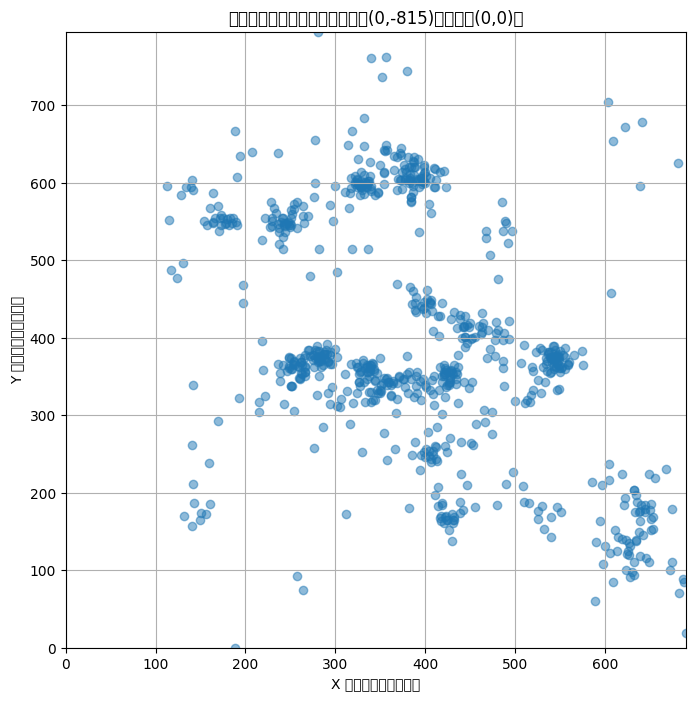

In [41]:
# 不再是将左下角实际点变为(0,0)，
# 而是将左下边界(0, -815)映射为(0, 0)，其他点相应变化（即 y_new = y_old + 815 ）
# X坐标不需调整，Y坐标整体加815

points_df_moved = points_df.copy()
points_df_moved['X坐标'] = points_df_moved['X坐标']
points_df_moved['Y坐标(已反转)'] = points_df_moved['Y坐标(已反转)'] + 815

display(points_df_moved)

plt.figure(figsize=(8,8))
plt.scatter(points_df_moved['X坐标'], points_df_moved['Y坐标(已反转)'], alpha=0.5)
plt.title('所有答卷点的分布（左下角边界(0,-815)已对齐为(0,0)）')
plt.xlabel('X 坐标（边界平移后）')
plt.ylabel('Y 坐标（边界平移后）')
plt.xlim(0, points_df_moved['X坐标'].max())
plt.ylim(0, points_df_moved['Y坐标(已反转)'].max())
plt.grid(True)
plt.show()


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754

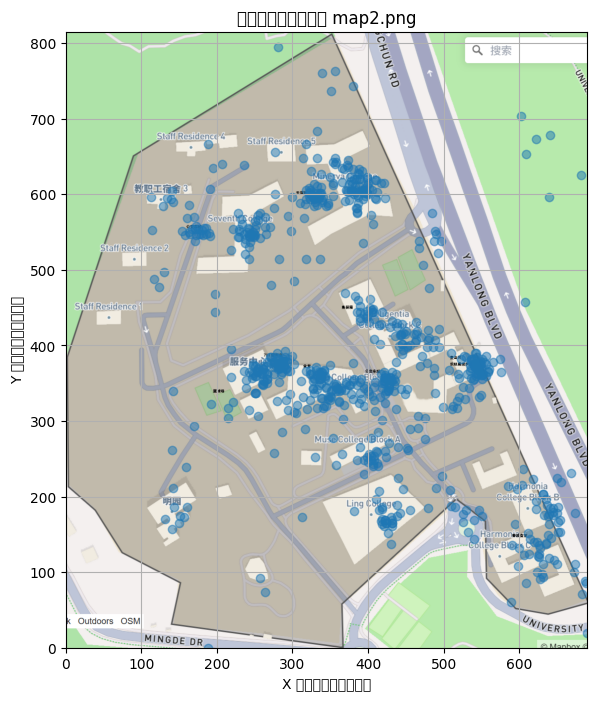

In [44]:
import matplotlib.image as mpimg

# 叠加map2.png作为背景
img = mpimg.imread('map2.png')

fig, ax = plt.subplots(figsize=(8,8))
# 直接按照图片坐标显示，不再设置origin='lower'
ax.imshow(img, extent=[0, 690, 0, 815])  # 默认origin='upper'，和图片坐标一致
ax.scatter(points_df_moved['X坐标'], points_df_moved['Y坐标(已反转)'], alpha=0.5)
ax.set_title('所有答卷点分布叠加 map2.png')
ax.set_xlabel('X 坐标（边界平移后）')
ax.set_ylabel('Y 坐标（边界平移后）')
ax.set_xlim(0, 690)
ax.set_ylim(0, 815)
ax.grid(True)
plt.show()
